# Study 7 · Staffing-controlled routing
## Partial pilot evidence and runtime diagnosis

**Status: halted at the runtime acceptance gate, not a completed eight-game result.**
Seven accepted episodes are preserved. The eighth exceeded the registered 500 ms
policy limit; its exact maximum and rejected payload were not saved. No game was
rerun for this audit. Historical notebooks 00–02 and their receipts are unchanged.

This notebook separates three questions: what the accepted episodes show,
which candidate representations activate, and why the implementation was slow.
Source: versioned AWS checkpoint audit, with exact report and table hashes.

In [1]:
import io
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "reports").is_dir():
    ROOT = ROOT.parent
report = json.loads((ROOT / "reports/staffing_audit_summary.json").read_text())
games = pd.read_csv(ROOT / "reports/staffing_observed_games.csv")
coverage = pd.read_csv(ROOT / "reports/staffing_feature_coverage.csv")
assert report["status"] == "HALTED_LATENCY_LIMIT"
assert report["accepted_games"] == 7 and report["expected_games"] == 8
assert report["published_eight_game_score"] is None


def show_figure(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=150, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


display(
    pd.DataFrame(
        {
            "checkpoint": [
                "Accepted episodes",
                "Registered episodes",
                "New audit games",
                "Snapshot vectors checked",
                "Farm actions checked",
            ],
            "count": [7, 8, 0, 161, 69],
        }
    )
)

,checkpoint,count
0,Accepted episodes,7
1,Registered episodes,8
2,New audit games,0
3,Snapshot vectors checked,161
4,Farm actions checked,69


### 1. Accepted episodes — retain the missing result
Both arms use the same base hiring/market rule; only final-day farm routing changes.
The seven rows below are observed results, not a pooled eight-game win rate.
The missing row is coordinated / seed 1602 / seat 1. Its result is unknown.
Local match score is 1 for a win, 0.5 for a tie and 0 for a loss; it is not
the Kaggle ladder rating. The 500 ms rule still applies to real policy callbacks.

In [2]:
columns = [
    "seed",
    "seat",
    "arm",
    "coins",
    "coin_margin",
    "match_score",
    "terminal_residual_product_units",
    "policy_latency_max_ms",
]
display(games[columns].round(2))
print("Missing:", report["failed_attempt"])
print("No complete eight-game score has been computed.")

,seed,seat,arm,coins,coin_margin,match_score,terminal_residual_product_units,policy_latency_max_ms
0,1601,0,sequential,44837.0,759.0,1.0,0,366.93
1,1601,0,coordinated,44840.0,758.0,1.0,0,447.70
2,1601,1,sequential,44837.0,759.0,1.0,0,322.46
3,1601,1,coordinated,44840.0,758.0,1.0,0,432.39
4,1602,0,sequential,50872.0,1228.0,1.0,14,357.68
5,1602,0,coordinated,51764.0,2115.0,1.0,1,394.73
6,1602,1,sequential,50102.0,-47.0,0.0,17,338.77


Missing: {'arm': 'coordinated', 'maximum_latency_ms': None, 'note': 'Original maximum and rejected payload were not saved', 'opponent': 'livestock_fertilizer', 'outcome': None, 'reason': 'Registered policy latency budget exceeded', 'seat': 1, 'seed': 1602}
No complete eight-game score has been computed.


### 2. Routing contribution — paired evidence is mixed
All three complete pairs had identical legal observation/action history before
day 29. Their match-score differences were zero. Coin margin changed by -1, -1,
and +887. The third pair also reduced unsold residual products from 14 to 1.
These are descriptive completed-pair results from a latency-censored pilot;
they do not establish a general improvement, and no confidence interval is claimed.

,coin_margin_difference,identical_preterminal,match_score_difference,seat,seed
0,-1.0,True,0.0,0,1601
1,-1.0,True,0.0,1,1601
2,887.0,True,0.0,0,1602


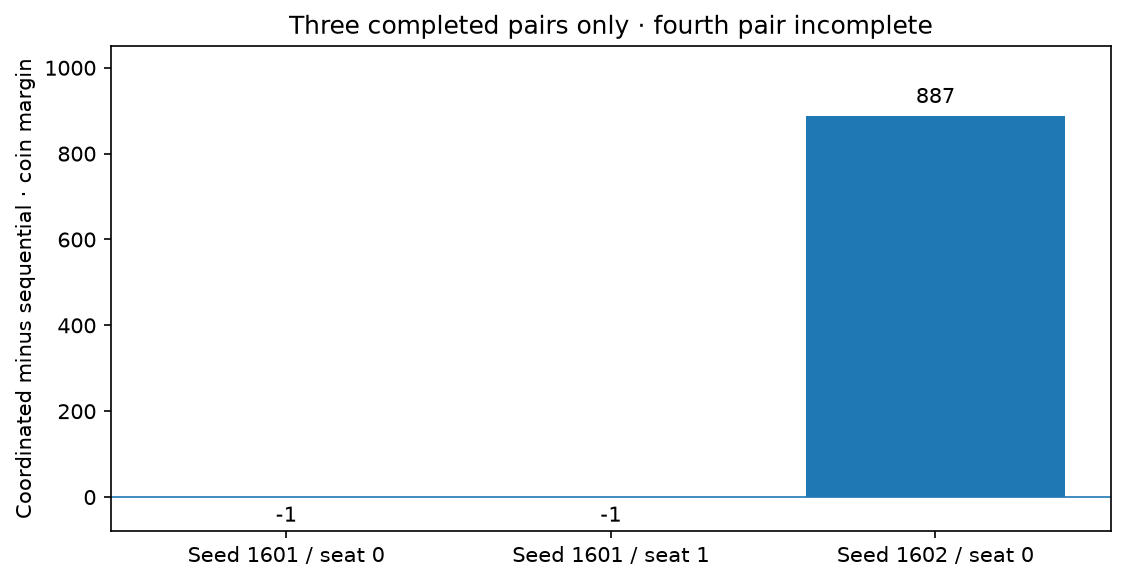

In [3]:
pairs = pd.DataFrame(report["completed_pairs"])
display(pairs)
labels = [f"Seed {r.seed} / seat {r.seat}" for r in pairs.itertuples()]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
bars = ax.bar(labels, pairs.coin_margin_difference)
ax.axhline(0, linewidth=0.8)
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set_ylabel("Coordinated minus sequential · coin margin")
ax.set_title("Three completed pairs only · fourth pair incomplete")
ax.set_ylim(-80, 1050)
show_figure(fig)

### 3. Representation coverage is not predictive selection
The 53 observation-only candidates span coordination constraints, worker-specific
opportunity and marginal assignment value. Of 161 final-day observations,
51 columns vary and two are constant. The two constants are expected in this
slice: final-day status and presence of the main farmer.

Variation establishes coverage, not value on the official metric. No feature was
selected for a final model. Important family ablations and stability across more
seeds, opponent policies, and earlier days remain outstanding. The field
`active_routed_workers` describes the proposed assignment, not a universal count
of actually executed coordinated worker actions in the sequential arm.

,candidates,varying,constant
family,,,
staffing_coordination,21,20,1
staffing_marginal_worker_value,4,4,0
staffing_worker_opportunity,28,27,1


,feature,minimum,maximum
4,staffing.final_day,1.0,1.0
30,staffing.worker0.present,1.0,1.0


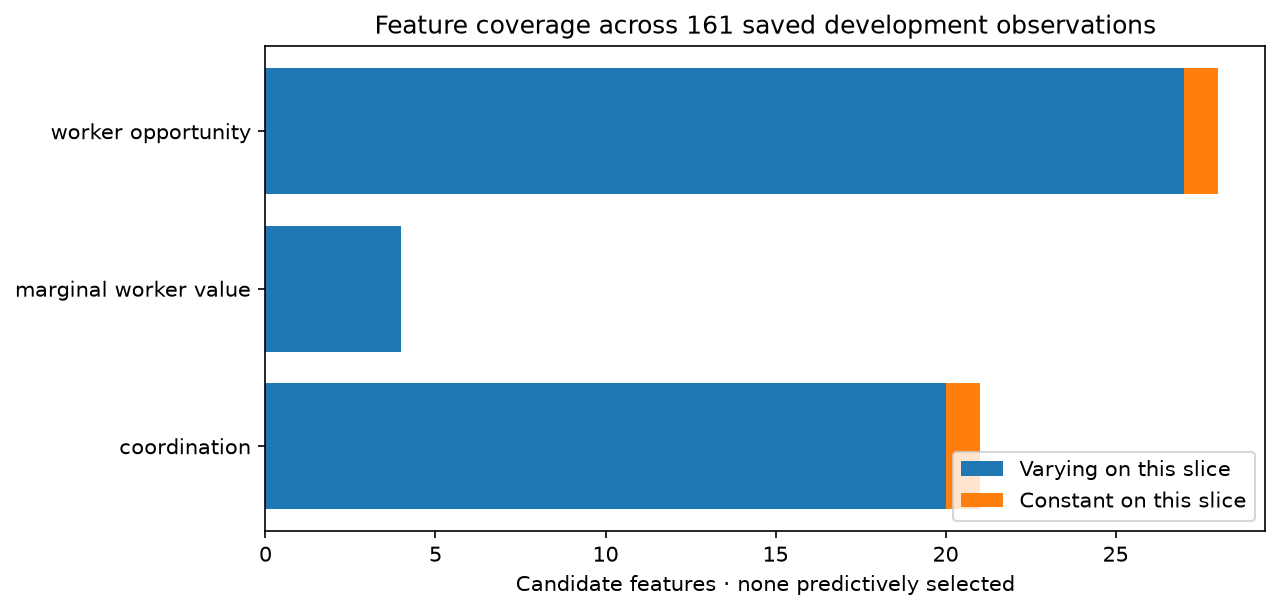

In [4]:
family = (
    coverage.assign(varying=coverage.distinct_values > 1)
    .groupby("family")
    .agg(candidates=("feature", "size"), varying=("varying", "sum"))
)
family["constant"] = family.candidates - family.varying
display(family)
display(coverage.loc[coverage.distinct_values == 1, ["feature", "minimum", "maximum"]])
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [name.replace("staffing_", "").replace("_", " ") for name in family.index]
positions = np.arange(len(labels))
ax.barh(positions, family.varying, label="Varying on this slice")
ax.barh(positions, family.constant, left=family.varying, label="Constant on this slice")
ax.set_yticks(positions, labels)
ax.set_xlabel("Candidate features · none predictively selected")
ax.set_title("Feature coverage across 161 saved development observations")
ax.legend(loc="lower right")
show_figure(fig)

### 4. Runtime mechanism — exact cumulative price curves
The frozen assignment code recomputed sale revenue independently for every
quantity. A single cumulative curve can preserve the same price-floor and
inventory transitions while avoiding quadratic repeated work. The search order,
exclusion constraints and tie-breaking were retained.

The candidate matched all 161 saved feature vectors and all 69 coordinated farm
actions plus diagnostics exactly. On three saved slow snapshots, three alternating
repetitions each show the timings below. This measures **features plus routing**,
not full end-to-end policy latency. The candidate has not been promoted. The real
AWS failure means an earlier explanation attributing the issue only to CI scheduling
was insufficient; profiling establishes redundant price calculations as a bottleneck.

,seed,seat,step,reference_median_ms,candidate_median_ms,median_speedup,reference_market_price_calls,candidate_market_price_calls
0,1601,0,702,370.05,31.42,11.78,277566,10266
1,1601,1,709,358.54,19.39,18.49,274650,7350
2,1602,0,699,382.92,41.75,9.17,280652,13352


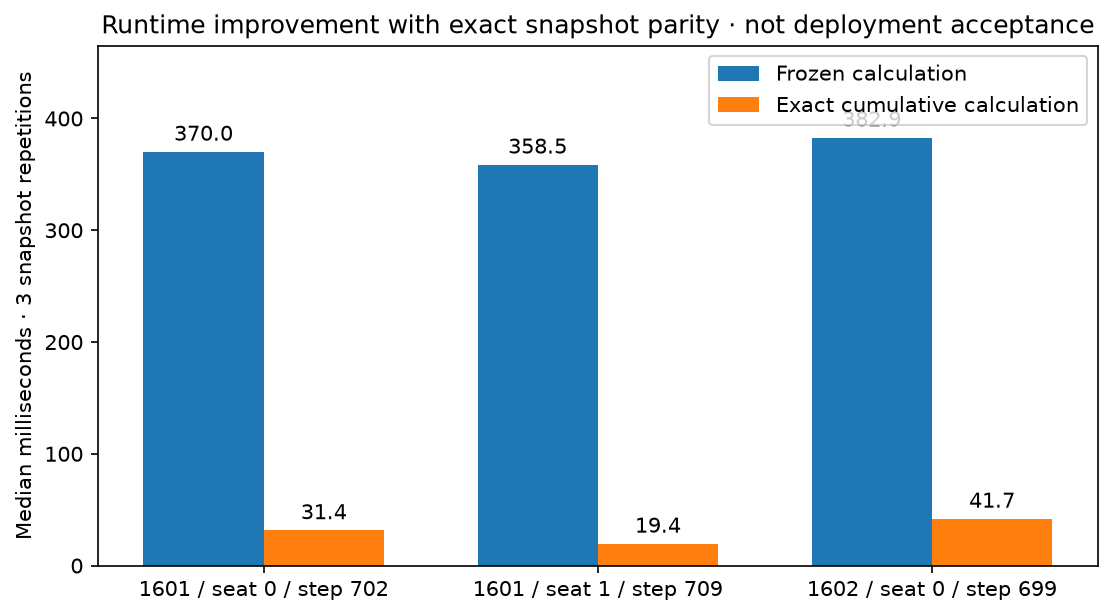

In [5]:
timing = pd.DataFrame(report["runtime_candidate"]["measurements"])
display(
    timing[
        [
            "seed",
            "seat",
            "step",
            "reference_median_ms",
            "candidate_median_ms",
            "median_speedup",
            "reference_market_price_calls",
            "candidate_market_price_calls",
        ]
    ].round(2)
)
positions = np.arange(len(timing))
fig, ax = plt.subplots(figsize=(8.6, 4.5))
first = ax.bar(positions - 0.18, timing.reference_median_ms, width=0.36, label="Frozen calculation")
second = ax.bar(
    positions + 0.18, timing.candidate_median_ms, width=0.36, label="Exact cumulative calculation"
)
ax.bar_label(first, fmt="%.1f", padding=3)
ax.bar_label(second, fmt="%.1f", padding=3)
ax.set_xticks(positions, [f"{r.seed} / seat {r.seat} / step {r.step}" for r in timing.itertuples()])
ax.set_ylim(0, 465)
ax.set_ylabel("Median milliseconds · 3 snapshot repetitions")
ax.set_title("Runtime improvement with exact snapshot parity · not deployment acceptance")
ax.legend(loc="upper right")
show_figure(fig)

### 5. Decision and next research gates
Keep the original pilot halted and preserve its seven accepted checkpoints.
Before another live experiment, measure the complete optimized callback, save
rejected payloads and their timing before rejecting them, and preregister a new
source identity. Do not retrofit new timings into the original study.

Feature research remains open: shared-capacity/task-conflict ablations, worker
marginal value versus wage and distance, season-long coordination, opponent supply
uncertainty, demand/scarcity regimes, and opponent-diverse evaluation are proposed
next questions, not completed feature families.

**Provenance caveat:** CI exercised seed 1601 before the AWS registration. That seed
is development evidence, not an untouched confirmatory sample. The original
registration is preserved; this disclosure corrects its overly broad claim.

In [6]:
print("Frozen pilot source:", report["source_commit"])
print("Audit implementation:", report["audit_code_commit"])
print("Original report SHA256:", report["source_artifact"]["sha256"])
print("Original report S3 version:", report["source_artifact"]["version_id"])
print("Feature research:", report["feature_completion_gate"])
print("Prior exposure:", report["registration_caveat"])
for limitation in report["limitations"]:
    print("Limitation:", limitation)

Frozen pilot source: f5c63727b2996f6154b07e4e26c6bfbb899d8559
Audit implementation: 1e5f6e0bcb8e1bcb222875f1d68aa763fd9ead63
Original report SHA256: a60c1c67694cf1034b3ec60efdfd4ae7722f9d4d64f7c16bf0041fb475b3f1cc
Original report S3 version: 4aA5DO.vasQfDBY7TF5HzJB4Fj.ELqjy
Feature research: open_research
Prior exposure: CI exercised seed 1601 before AWS registration; it is not untouched evidence
Limitation: Latency-censored partial pilot; not an eight-game result
Limitation: One opponent and two seeds cannot establish population strength
Limitation: Snapshot parity is not a complete live deployment acceptance test
Limitation: Original maximum-latency value and eighth-game payload were not saved
